<a href="https://colab.research.google.com/github/Bird308/Bird308.github.io/blob/main/regression_intuition_cars_interaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What Is a Regression Coefficient, Really?

**BADM 576 | Data Science and Analytics | Spring 2026**

---

We'll use 30 used cars to build your intuition from scratch.

By the end, you'll be able to explain to a non-technical person:
- What a regression coefficient actually is
- Why a coefficient can be **misleading** without controls
- What "holding all else constant" means — mechanically, not just as a phrase

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

np.random.seed(576)

# --- Generate 30 used cars ---
n = 30
car_type = np.array(['Luxury']*15 + ['Economy']*15)

# Luxury cars tend to be older in this sample (owners hold onto them)
age = np.where(car_type == 'Luxury',
               np.random.uniform(3, 10, n),
               np.random.uniform(1, 6, n)).round(1)

# Price depends on type AND age
price = np.where(car_type == 'Luxury',
                 45000 - 2000*age + np.random.normal(0, 2000, n),
                 22000 - 1500*age + np.random.normal(0, 1500, n)).round(0)

cars = pd.DataFrame({'price': price, 'age': age, 'type': car_type})

In [ ]:
cars

,price,age,type
0,28680.0,7.4,Luxury
1,27862.0,9.4,Luxury
2,26938.0,9.4,Luxury
3,23001.0,8.3,Luxury
4,34448.0,4.3,Luxury
5,37742.0,4.2,Luxury
6,34605.0,4.1,Luxury
7,30020.0,7.3,Luxury
8,31530.0,5.5,Luxury
9,32355.0,5.5,Luxury


In [ ]:
print('Summary by type:')
print(cars.groupby('type')[['price', 'age']].mean().round(0))
print(f'\nOverall correlation between price and age: {np.corrcoef(cars["price"], cars["age"])[0,1]:.3f}')

Summary by type:
           price  age
type                 
Economy  16892.0  3.0
Luxury   31750.0  6.0

Overall correlation between price and age: 0.312


Notice two things:
1. Luxury cars are **older on average** (6 years vs 3 years)
2. Luxury cars are **more expensive** ($31,750 vs $16,892)

And the overall correlation between price and age is **positive** (~0.31). Older cars cost more? That seems wrong. Let's see what regression says.

---
## 1: A Coefficient Is Just a Slope

The simplest regression: one X, one Y.

In [ ]:
# Simple regression: price on age
m1 = smf.ols('price ~ age', data=cars).fit()

print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     3.012
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0937
Time:                        20:24:42   Log-Likelihood:                -311.26
No. Observations:                  30   AIC:                             626.5
Df Residuals:                      28   BIC:                             629.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.872e+04   3544.863      5.281      0.0

In [ ]:
print('price = {:.0f} + {:.0f} × age'.format(m1.params['Intercept'], m1.params['age']))
print(f'\nCoefficient on age: +${m1.params["age"]:,.0f}')
print(f'R-squared: {m1.rsquared:.3f}')

price = 18720 + 1147 × age

Coefficient on age: +$1,147
R-squared: 0.097


**What is the interpretation of the coefficient of age?**

The model says: **each additional year of age is associated with +$1,147 in price.**

Older cars cost more? Something is off. But let's first understand what this number actually is.

**Think about it (team exercise):**

1. What would the coefficient be if **age** was measured in **months** instead of years?
2. What would the coefficient be if **price** was measured in **thousands of dollars** and **age** in years?

The coefficient's value depends on the units of measurement. So how do we compare coefficients across variables with different scales?

### Standardization: Making Variables Unitless

Let's make both variables unitless by scaling them to mean = 0 and std = 1 (z-scores).

In [ ]:
# Standardize both variables
cars['price_z'] = (cars['price'] - cars['price'].mean()) / cars['price'].std()
cars['age_z'] = (cars['age'] - cars['age'].mean()) / cars['age'].std()

cars.describe()

Now let's run the regression on these standardized variables and see what the coefficient tells us.

In [ ]:
# Regression with standardized variables
m_std = smf.ols('price_z ~ age_z', data=cars).fit()

print('Correlation between price and age:', round(cars['price'].corr(cars['age']), 3))
print()
print(m_std.summary())

In [ ]:
# The connection: coefficient = correlation × (SD_y / SD_x)
r = cars['price'].corr(cars['age'])
sd_price = cars['price'].std()
sd_age = cars['age'].std()

print('The coefficient is just the correlation, rescaled to data units:')
print(f'\n  Correlation (r):          {r:.3f}')
print(f'  SD of price:              ${sd_price:,.0f}')
print(f'  SD of age:                {sd_age:.2f} years')
print(f'\n  r × (SD_price / SD_age) = {r:.3f} × ({sd_price:,.0f} / {sd_age:.2f}) = ${r * sd_price / sd_age:,.0f}')
print(f'  Regression coefficient  = ${m1.params["age"]:,.0f}')
print(f'\n  ✓ Same number. The coefficient IS the correlation in different units.')

**Takeaway from 1:** There's nothing magical about a regression coefficient. In a simple regression, it's just the correlation rescaled to the units of your data. Standardize both variables and the coefficient *becomes* the correlation.

---
## 2: This Coefficient Is Lying to Us

The model says older cars cost more. But we know that's not how cars work.

Let's look at the data more carefully.

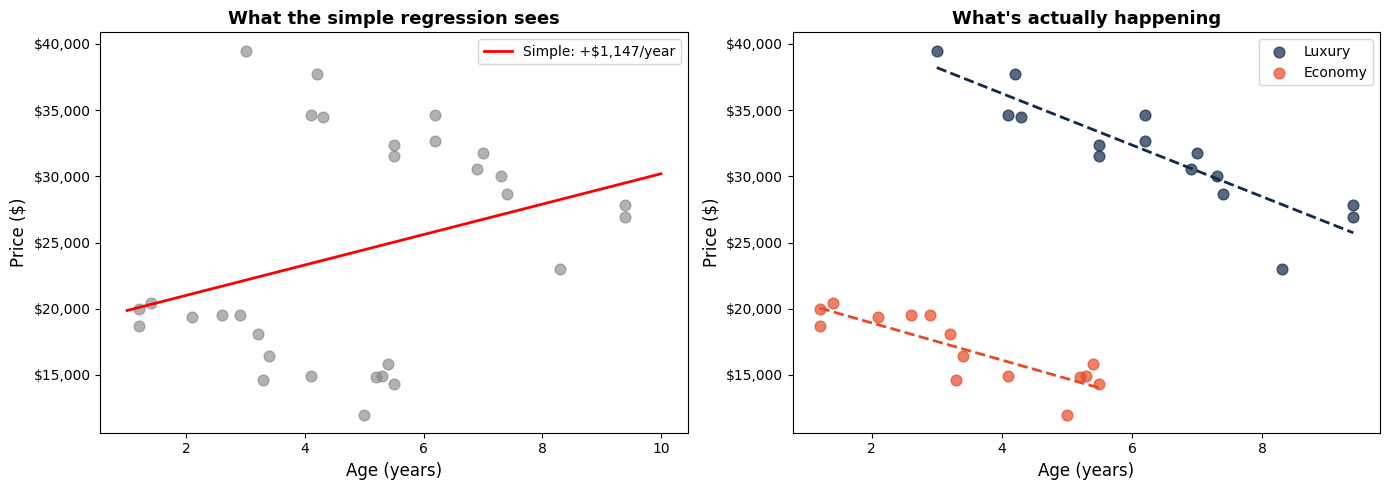

Left:  One regression line through all 30 cars → slopes UP (misleading)
Right: Two separate lines by type → both slope DOWN (correct)

The simple regression was picking up the DIFFERENCE BETWEEN groups,
not the relationship WITHIN groups.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: simple regression (misleading)
ax = axes[0]
ax.scatter(cars['age'], cars['price'], color='gray', alpha=0.6, s=60)
age_line = np.linspace(1, 10, 100)
ax.plot(age_line, m1.params['Intercept'] + m1.params['age'] * age_line,
        color='red', linewidth=2, label=f'Simple: +${m1.params["age"]:,.0f}/year')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.set_title('What the simple regression sees', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Right plot: colored by type (the truth)
ax = axes[1]
colors = {'Luxury': '#13294B', 'Economy': '#E84A27'}
for t in ['Luxury', 'Economy']:
    subset = cars[cars['type'] == t]
    ax.scatter(subset['age'], subset['price'], color=colors[t],
              alpha=0.7, s=60, label=t)
    # Within-group regression line
    m_sub = smf.ols('price ~ age', data=subset).fit()
    age_range = np.linspace(subset['age'].min(), subset['age'].max(), 50)
    ax.plot(age_range, m_sub.params['Intercept'] + m_sub.params['age'] * age_range,
            color=colors[t], linewidth=2, linestyle='--')

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.set_title('What\'s actually happening', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

print('Left:  One regression line through all 30 cars → slopes UP (misleading)')
print('Right: Two separate lines by type → both slope DOWN (correct)')
print('\nThe simple regression was picking up the DIFFERENCE BETWEEN groups,')
print('not the relationship WITHIN groups.')

**What happened?** Luxury cars are both *older* and *more expensive*. So the simple regression saw "older → pricier" — but it was really seeing "luxury → pricier" in disguise. Age was acting as a **proxy for car type**.

This is **confounding**. Type is connected to both age (luxury cars are older) and price (luxury cars cost more). Without accounting for type, the age coefficient absorbs type's effect.

### ✏️ Question 1

Can you think of a real-world example where a simple correlation between two variables is misleading because of a lurking third variable? Describe the three variables and explain why the simple relationship is misleading.

**Your answer:** *(double-click to edit)*



### A Potential Solution: Fit Separate Models

One idea: fit a separate regression for each car type.

In [ ]:
# Split by type
cars_lux = cars[cars['type'] == 'Luxury']
cars_eco = cars[cars['type'] == 'Economy']

print('=== Luxury Cars ===')
print(f'Correlation (price, age): {np.corrcoef(cars_lux["price"], cars_lux["age"])[0,1]:.3f}')
m1_lux = smf.ols('price ~ age', data=cars_lux).fit()
print(f'Coefficient on age: ${m1_lux.params["age"]:,.0f}')
print(f'R-squared: {m1_lux.rsquared:.3f}')

print('\n=== Economy Cars ===')
print(f'Correlation (price, age): {np.corrcoef(cars_eco["price"], cars_eco["age"])[0,1]:.3f}')
m1_eco = smf.ols('price ~ age', data=cars_eco).fit()
print(f'Coefficient on age: ${m1_eco.params["age"]:,.0f}')
print(f'R-squared: {m1_eco.rsquared:.3f}')

print(f'\nBoth slopes are NEGATIVE — within each type, older cars cost less.')
print(f'The simple regression\'s positive slope was an artifact of mixing the groups.')

**Think about it:**
- What would the coefficient values be if the data within each group were standardized?
- This solution works, but it's inefficient. What if there were 100 car brands — should we run 100 separate regressions?

Is there a more efficient way?

---
## 3: Multiple Regression Fixes This

Add car type to the model. Watch what happens to the age coefficient.

In [ ]:
# Multiple regression: price on age AND type
m2 = smf.ols('price ~ age + type', data=cars).fit()

print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     300.6
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           3.54e-19
Time:                        20:01:36   Log-Likelihood:                -265.59
No. Observations:                  30   AIC:                             537.2
Df Residuals:                      27   BIC:                             541.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       2.287e+04    807.629     28.

In [ ]:
print('THE COEFFICIENT FLIPPED SIGN.')
print(f'\n  Simple regression (age alone):  +${m1.params["age"]:,.0f} per year')
print(f'  Multiple regression (+ type):   ${m2.params["age"]:,.0f} per year')
print(f'\n  R² went from {m1.rsquared:.3f} to {m2.rsquared:.3f}')
print(f'\nThe simple model said older cars cost MORE.')
print(f'The multiple model says older cars cost LESS — about ${abs(m2.params["age"]):,.0f} per year.')
print(f'\nThe type coefficient says luxury cars are worth about')
print(f'${m2.params["type[T.Luxury]"]:,.0f} more than economy cars of the same age.')
print(f'\nThis is what "holding all else constant" means:')
print(f'  - The age coefficient compares cars OF THE SAME TYPE')
print(f'  - The type coefficient compares cars OF THE SAME AGE')

THE COEFFICIENT FLIPPED SIGN.

  Simple regression (age alone):  +$1,147 per year
  Multiple regression (+ type):   $-1,731 per year

  R² went from 0.097 to 0.957

The simple model said older cars cost MORE.
The multiple model says older cars cost LESS — about $1,731 per year.

The type coefficient says luxury cars are worth about
$19,807 more than economy cars of the same age.

This is what "holding all else constant" means:
  - The age coefficient compares cars OF THE SAME TYPE
  - The type coefficient compares cars OF THE SAME AGE


### ✏️ Question 2

A 5-year-old Luxury car and a 5-year-old Economy car.

Using the equation above, calculate the predicted price for each. What is the difference? Does it match the type coefficient?

**Your answer:** *(double-click to edit)*



In [ ]:
# Verify your answer
econ_5yr = m2.params['Intercept'] + m2.params['age'] * 5
lux_5yr = m2.params['Intercept'] + m2.params['age'] * 5 + m2.params['type[T.Luxury]']

print(f'Economy, 5 years old: ${econ_5yr:,.0f}')
print(f'Luxury,  5 years old: ${lux_5yr:,.0f}')
print(f'Difference:           ${lux_5yr - econ_5yr:,.0f}')
print(f'Type coefficient:     ${m2.params["type[T.Luxury]"]:,.0f}')
print(f'\n✓ The difference between any Luxury and Economy car of the same age')
print(f'  is always exactly the type coefficient.')

Economy, 5 years old: $14,216
Luxury,  5 years old: $34,023
Difference:           $19,807
Type coefficient:     $19,807

✓ The difference between any Luxury and Economy car of the same age
  is always exactly the type coefficient.


---
## 4: What Does "Controlling For" Actually Mean?

**The idea:** Strip out type's influence from BOTH price and age. Then see what's left.

In [ ]:
# Step 1: Remove type's effect from PRICE
# Regress price on type, take the residuals.
# The residual = how far is this car from its group mean?

m_price_type = smf.ols('price ~ type', data=cars).fit()
cars['price_resid'] = m_price_type.resid

print('Step 1: Remove type effect from PRICE')
print(f'  Luxury mean price:  ${cars[cars["type"]=="Luxury"]["price"].mean():,.0f}')
print(f'  Economy mean price: ${cars[cars["type"]=="Economy"]["price"].mean():,.0f}')
print(f'\n  Residual = car\'s price minus its group mean')
print(f'  Example: A luxury car priced at $28,000 → residual = $28,000 - $31,750 = -$3,750')
print(f'  This is "price with the type difference stripped out"')
print(f'\nFirst 5 cars:')
print(cars[['type', 'price', 'price_resid']].head().to_string(index=False))

In [ ]:
# Step 2: Remove type's effect from AGE
# Same idea — residual = how much older/younger than its group average?

m_age_type = smf.ols('age ~ type', data=cars).fit()
cars['age_resid'] = m_age_type.resid

print('Step 2: Remove type effect from AGE')
print(f'  Luxury mean age:  {cars[cars["type"]=="Luxury"]["age"].mean():.1f} years')
print(f'  Economy mean age: {cars[cars["type"]=="Economy"]["age"].mean():.1f} years')
print(f'\n  Residual = car\'s age minus its group mean')
print(f'  Example: A luxury car aged 9 years → residual = 9 - 6.3 = +2.7')
print(f'  This is "age with the type difference stripped out"')
print(f'\nFirst 5 cars:')
print(cars[['type', 'age', 'age_resid']].head().to_string(index=False))

In [ ]:
# Step 3: Regress the residuals on each other
m_partial = smf.ols('price_resid ~ age_resid', data=cars).fit()

print('Step 3: Regress price residuals on age residuals')
print(f'\n  Coefficient from partialling out: ${m_partial.params["age_resid"]:,.0f}')
print(f'  Coefficient from multiple reg:    ${m2.params["age"]:,.0f}')
print(f'\n  ✓ IDENTICAL.')
print(f'\n  "Controlling for type" literally means:')
print(f'  1. Remove type\'s influence from price')
print(f'  2. Remove type\'s influence from age')
print(f'  3. See what\'s left')
print(f'\n  That\'s it. No magic. No black box.')

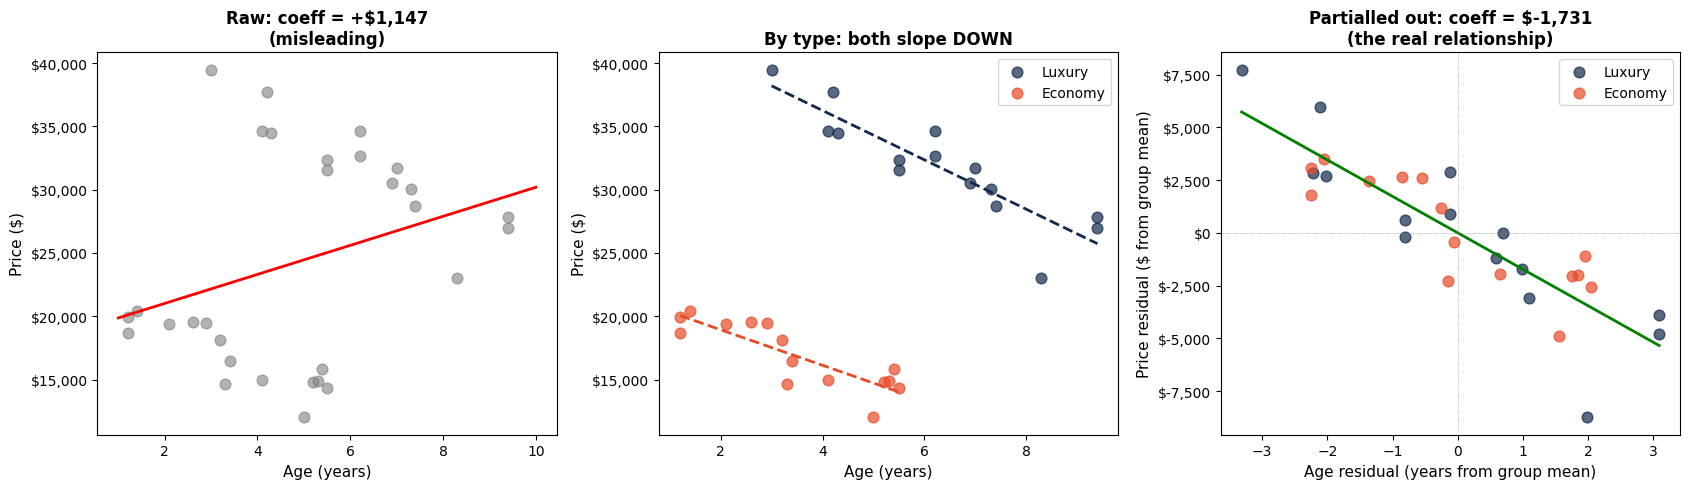

Left:   Raw data → positive slope (confounded)
Middle: Colored by type → negative slopes within each group
Right:  After partialling out type → both groups overlap, negative slope
        This IS what multiple regression computes.


In [ ]:
# Visualize: the partialled-out relationship
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1: Raw data — misleading
ax = axes[0]
ax.scatter(cars['age'], cars['price'], color='gray', alpha=0.6, s=60)
age_line = np.linspace(1, 10, 100)
ax.plot(age_line, m1.params['Intercept'] + m1.params['age'] * age_line,
        color='red', linewidth=2)
ax.set_xlabel('Age (years)', fontsize=11)
ax.set_ylabel('Price ($)', fontsize=11)
ax.set_title(f'Raw: coeff = +${m1.params["age"]:,.0f}\n(misleading)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 2: Colored by type
ax = axes[1]
for t in ['Luxury', 'Economy']:
    subset = cars[cars['type'] == t]
    ax.scatter(subset['age'], subset['price'], color=colors[t],
              alpha=0.7, s=60, label=t)
    m_sub = smf.ols('price ~ age', data=subset).fit()
    age_range = np.linspace(subset['age'].min(), subset['age'].max(), 50)
    ax.plot(age_range, m_sub.params['Intercept'] + m_sub.params['age'] * age_range,
            color=colors[t], linewidth=2, linestyle='--')
ax.set_xlabel('Age (years)', fontsize=11)
ax.set_ylabel('Price ($)', fontsize=11)
ax.set_title('By type: both slope DOWN', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 3: Residuals — the partialled-out relationship
ax = axes[2]
for t in ['Luxury', 'Economy']:
    subset = cars[cars['type'] == t]
    ax.scatter(subset['age_resid'], subset['price_resid'], color=colors[t],
              alpha=0.7, s=60, label=t)
resid_line = np.linspace(cars['age_resid'].min(), cars['age_resid'].max(), 100)
ax.plot(resid_line, m_partial.params['Intercept'] + m_partial.params['age_resid'] * resid_line,
        color='green', linewidth=2)
ax.axhline(y=0, color='gray', linewidth=0.5, linestyle=':')
ax.axvline(x=0, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel('Age residual (years from group mean)', fontsize=11)
ax.set_ylabel('Price residual ($ from group mean)', fontsize=11)
ax.set_title(f'Partialled out: coeff = ${m_partial.params["age_resid"]:,.0f}\n(the real relationship)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

print('Left:   Raw data → positive slope (confounded)')
print('Middle: Colored by type → negative slopes within each group')
print('Right:  After partialling out type → both groups overlap, negative slope')
print('        This IS what multiple regression computes.')

### ✏️ Question 3

In the third plot (residuals), the two groups overlap — luxury and economy cars are mixed together. Why?

*(Hint: what did we remove in Steps 1 and 2? What's left?)*

**Your answer:** *(double-click to edit)*



---
## 5: The Full Picture

Let's put it all together.

In [ ]:
print('=' * 65)
print('THE FULL STORY OF ONE COEFFICIENT')
print('=' * 65)
print(f'\n  Simple regression (age alone):     +${m1.params["age"]:>7,.0f} per year')
print(f'  Standardized = correlation:          {m_std.params["age_z"]:>7.3f}')
print(f'  Multiple regression (+ type):      ${m2.params["age"]:>7,.0f} per year')
print(f'  Partialled-out (residuals):        ${m_partial.params["age_resid"]:>7,.0f} per year')
print(f'\n' + '=' * 65)
print(f'\nKey insights:')
print(f'  1. A simple coefficient is a rescaled correlation. Nothing more.')
print(f'  2. It can be MISLEADING when another variable is connected')
print(f'     to both X and Y (here: type drives both age and price).')
print(f'  3. Multiple regression fixes this by partialling out the')
print(f'     confounding variable from BOTH sides.')
print(f'  4. "Controlling for" is not magic — it is subtracting out')
print(f'     the control variable\'s effect, then running the regression')
print(f'     on what remains.')

THE FULL STORY OF ONE COEFFICIENT

  Simple regression (age alone):     +$  1,147 per year
  Standardized = correlation:            0.312
  Multiple regression (+ type):      $ -1,731 per year
  Partialled-out (residuals):        $ -1,731 per year


Key insights:
  1. A simple coefficient is a rescaled correlation. Nothing more.
  2. It can be MISLEADING when another variable is connected
     to both X and Y (here: type drives both age and price).
  3. Multiple regression fixes this by partialling out the
     confounding variable from BOTH sides.
  4. "Controlling for" is not magic — it is subtracting out
     the control variable's effect, then running the regression
     on what remains.


### ✏️ Question 4

Imagine you're explaining this to a hiring manager who asks: *"Your model says experience is worth $3,876 per year. But when I run a simple average, it seems like more experienced people earn way more than that. Why is your number so low?"*

Using what you learned from the cars example, explain to them — in plain English — why the simple average is misleading and what the regression coefficient actually captures.

*(Hint: what might play the same role as "car type" in a salary context?)*

**Your answer:** *(double-click to edit)*



---
## 6: Beyond Averages — What If the Effect Differs by Group?

The multiple regression in Act 3 gave us **one** age coefficient: -$1,731 per year. That's the **average** depreciation rate, controlling for type.

But what if luxury cars and economy cars depreciate at **different rates**? The controlled model forces them to share the same slope. What if that's wrong?

This is where **interaction terms** come in.

In [ ]:
# Interaction model: let each type have its own slope
m_interact = smf.ols('price ~ age * type', data=cars).fit()

results_int = pd.DataFrame({
    'Coef': m_interact.params,
    'Std Err': m_interact.bse,
    'P>|t|': m_interact.pvalues,
}).round(2)
print(results_int.to_string())
print(f'\nR-squared: {m_interact.rsquared:.3f}')

In [ ]:
# What do these coefficients mean?
print('READING THE INTERACTION MODEL')
print('=' * 60)
print(f'\n  Economy car depreciation:  ${m_interact.params["age"]:,.0f} per year')
print(f'  (this is the "age" coefficient)')
print(f'\n  Luxury car depreciation:   ${m_interact.params["age"] + m_interact.params["age:type[T.Luxury]"]:,.0f} per year')
print(f'  (age + age:type interaction)')
print(f'\n  The interaction term ({m_interact.params["age:type[T.Luxury]"]:+,.0f}) tells us:')
print(f'  Luxury cars depreciate ${abs(m_interact.params["age:type[T.Luxury]"]):,.0f}/year MORE than economy cars.')
print(f'\n  Compare with the subgroup models from Act 2:')
print(f'  Economy slope: ${m1_eco.params["age"]:,.0f}   ← matches "age" coefficient')
print(f'  Luxury slope:  ${m1_lux.params["age"]:,.0f}   ← matches age + interaction')

**The key idea:**

- **Controlling for type** (Act 3: `price ~ age + type`) gives you the **average** effect of age across both types — one shared slope, just shifted up or down.
- **Interacting with type** (Act 6: `price ~ age * type`) gives you **separate** effects of age for each type — each group gets its own slope.

The controlled model asks: *"What is the typical depreciation rate, regardless of type?"*

The interaction model asks: *"Does the depreciation rate depend on type?"*

Both are valid questions. Which one you use depends on what you're trying to learn.

In the formula, the only difference is one character: `+` vs `*`.

### ✏️ Question 5

In the JobMatch data, we will model salary as a function of seniority, location, company size, and other features.

If you suspected that the **salary premium for seniority depends on industry** (e.g., a Lead in Technology earns a different premium than a Lead in Education), how would you write the formula?

What business question would the interaction coefficient answer?

**Your answer:** *(double-click to edit)*